In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct
# plt.style.use('mplstyle')

In [2]:


# ----------------------------
# 1) Define theory P(k_parallel)
# ----------------------------

# Theoretical continuous power spectrum: P(k) ∝ k^-n
n = 3.0
N = 768                # number of channels
dnuc = 40e-3            # MHz spacing (example)
rp = 16.98990953034521 # Mpc/MHz              # Mpc/Hz conversion
L = N * dnuc * rp      # LOS length

# continuous model grid for reference
k_model = np.logspace(-3, 6, 5000)
P_model = k_model**(-n)

print(f"LOS length = {L:.3f} Mpc")

# ----------------------------
# 2) FFT k-grid used by simulation
# ----------------------------

dx = L/N
k_fft = 2*np.pi * np.fft.fftfreq(N, d=dx)
k_abs = np.abs(k_fft)

# interpolate theory spectrum onto FFT grid
P_cont_fft = np.interp(k_abs, k_model, P_model, left=0, right=0)

# ----------------------------
# 3) Convert to discrete FFT variance
#    <|fk|^2> = (N^2/L) * P(k)
# ----------------------------

P_dft = (N**2 / L) * P_cont_fft


# ----------------------------------------------------
# 4) Gaussian random field generator (Hermitian-symmetric)
# ----------------------------------------------------

def draw_field_from_power(P_dft):
    fk = np.zeros(N, dtype=complex)

    fk[0] = np.sqrt(P_dft[0]) * np.random.randn()
    if N % 2 == 0:
        fk[N//2] = np.sqrt(P_dft[N//2]) * np.random.randn()

    for i in range(1, N//2):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(P_dft[i]/2)
        fk[i] = amp*(a + 1j*b)
        fk[-i] = np.conjugate(fk[i])

    return np.fft.ifft(fk).real


# ----------------------------
# 5) Simulate realizations
# ----------------------------

Nrea = 10
fields = np.array([draw_field_from_power(P_dft) for _ in range(Nrea)])
flag = pfunc.flagdata(N, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
ml = pfunc.covtocl_fast(flag, flag) # counter for normalizition 


# ----------------------------
# 6) Apply taper + correlation (MAPS step simplified)
# ----------------------------

window = nuttall(N)
pk_recovered = []

fact = L/N**2  # conversion back to continuous P(k)

for field in fields:

    # correlation estimator (replace with your covtocl_fast if desired)
    cl = np.correlate(field, field, mode='full')[N-1:]
    # cl = pfunc.covtocl_fast(field, field)/ml

    # apply taper + DCT estimator
    pk_dct = dct(cl * window, type=1) * (N-1)/2

    # scale back to continuous-theory normalization
    pk_recovered.append(pk_dct * fact)

pk_recovered = np.array(pk_recovered)


# ----------------------------
# 7) Window transfer function
# ----------------------------

Wk = 1 # np.abs(np.fft.fft(window))**2
W_interp = 1 # np.interp(k_abs, np.fft.fftfreq(N,d=dx), Wk)

P_theory_windowed = P_cont_fft * W_interp


# ----------------------------
# 8) Bin and compare theory vs recovered
# ----------------------------

def bin_linear(x, y, nbins):
    bins = np.linspace(min(x), max(x), nbins+1)
    out = []
    xc = []
    for i in range(nbins):
        mask = (x >= bins[i]) & (x < bins[i+1])
        if np.sum(mask)>0:
            out.append(np.mean(y[mask]))
            xc.append(np.mean(x[mask]))
    return np.array(xc), np.array(out)

# ----------------------------
# 8) Bin theory and recovered identically
# ----------------------------

NB = 32  # number of bins

# Build consistent bins based on FFT k-range (skip k=0)
k_vals = k_abs[1:]
bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(pk_recovered[i, 1:][mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# --- Bin the theory using the same bins ---
binned_th = np.zeros(NB)
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(P_theory_windowed[1:][mask])
    else:
        binned_th[j] = np.nan


LOS length = 521.930 Mpc


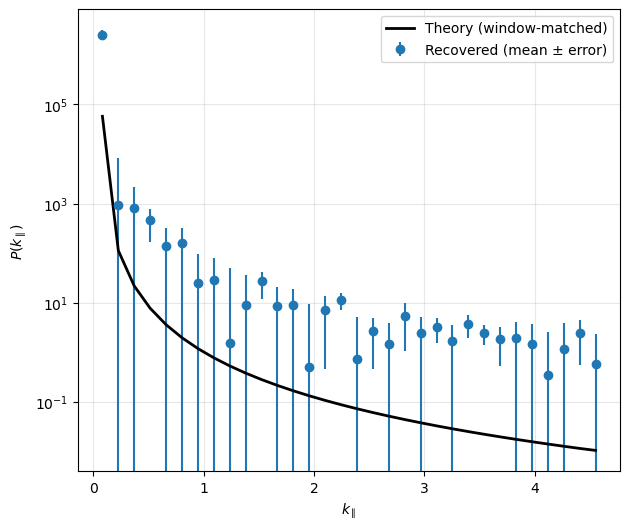

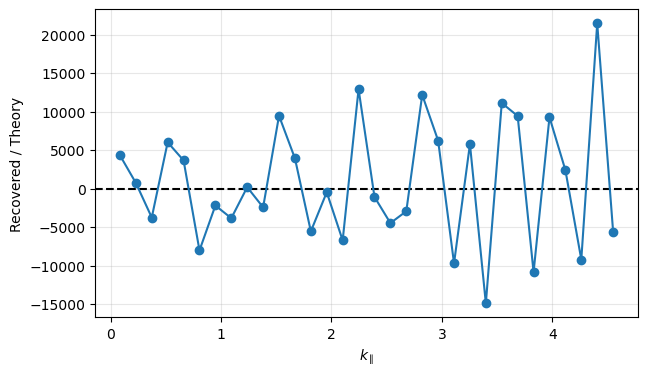

In [5]:
plt.figure(figsize=(7,6))
plt.errorbar(k_centers, abs(p_rec_mean), p_rec_err, fmt='o', label='Recovered (mean ± error)')
plt.plot(k_centers, binned_th, '-k', lw=2, label='Theory (window-matched)')
# plt.xscale('log');
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Ratio plot
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
err = p_rec_mean / binned_th - 1
plt.plot(k_centers, 100*err, 'o-')
# plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('Recovered / Theory')
plt.grid(alpha=0.3)
plt.show()


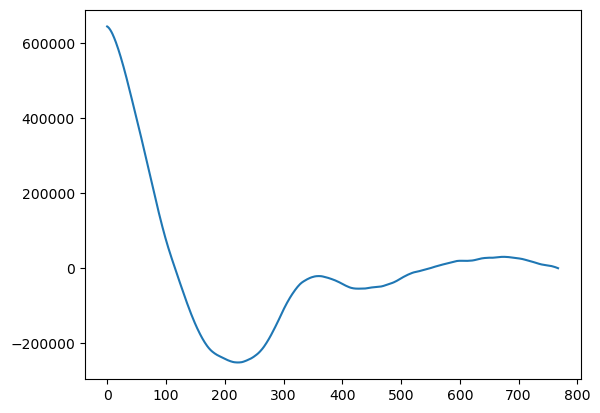

In [4]:
plt.plot(cl)